In [1]:
import numpy as np
import matplotlib.pyplot as plt
import plot_scripts as plts
plt.style.use("mplstyle")

In [4]:
path = 'results'
mode = 'NOFLAG'
# mode = 'RANDOM'
# mode = 'PERIODIC'
# mode = 'PERIODIC+RANDOM'
inp_signal = 'FG+MM+21cm'
inp_signal = 'FG+21cm'

SCF = 'None'
data = np.load(f"{path}/fft_inp_signal-{inp_signal}_flag-{mode}_SCF-{SCF}.npz")

kb_dct          = data["kb"]
mean_dct        = data["mean"]
err_dct         = data["err"]
binned_th_dct   = data["binned_th"]

inp_signal      = data["inp_signal"].tolist()
flag            = data["flag"].tolist()
scf             = data["SCF"].tolist()
print(f"inp_signal = {inp_signal}, flag = {flag}, scf = {scf}")

SCF1 = 'GP'
data = np.load(f"{path}/dct_inp_signal-{inp_signal}_flag-{mode}_SCF-{SCF1}.npz")

kb_dct1          = data["kb"]
mean_dct1        = data["mean"]
err_dct1         = data["err"]
binned_th_dct1   = data["binned_th"]

inp_signal      = data["inp_signal"].tolist()
flag            = data["flag"].tolist()
scf             = data["SCF"].tolist()
print(f"inp_signal = {inp_signal}, flag = {flag}, scf = {scf}")

inp_signal = FG+21cm, flag = NOFLAG, scf = None
inp_signal = FG+21cm, flag = NOFLAG, scf = GP


Saved: plots/SCFvNoSCF_Data_FG+21cm_Flag_NOFLAG.pdf


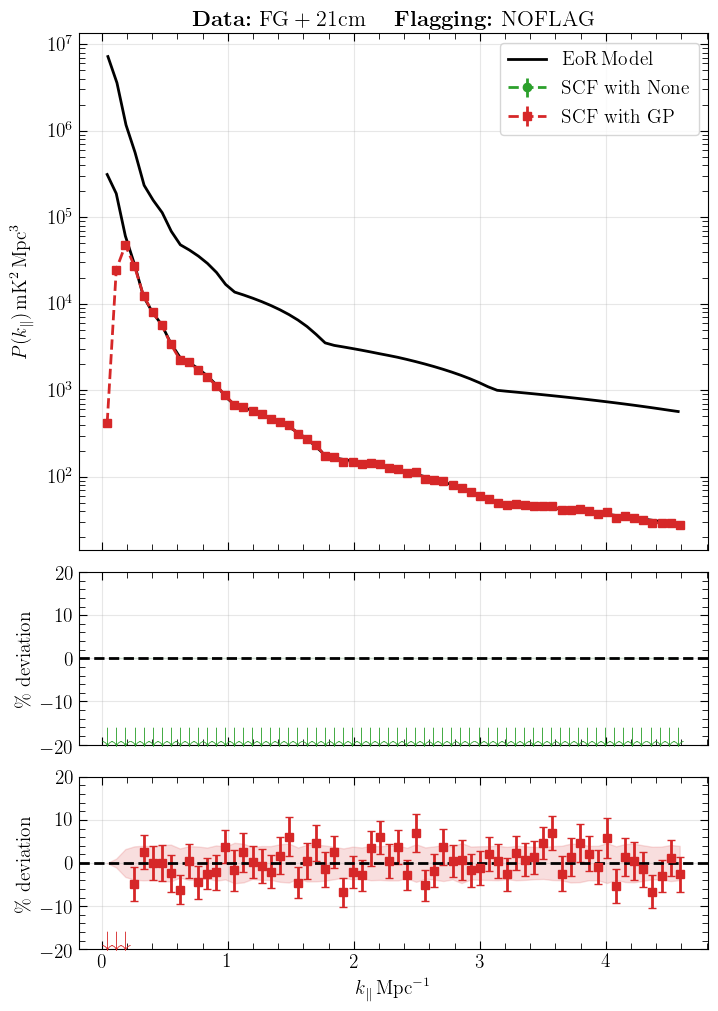

In [5]:
shift = 20   # upward shift for clarity
offset_ratio = 0  # shift 2 percentage points in ratio plot (optional)
figname = f"plots/SCFvNoSCF_Data_{inp_signal}_Flag_{mode}.pdf"  

if SCF==None:
    fft_label=r'${\rm No \ SCF}$'
else: 
    fft_label=fr'${{\rm SCF \ with \ {SCF} }}$'

fig, axes = plts.plot_compare_estimators(
    kb_dct, mean_dct * shift, err_dct*shift, binned_th_dct* shift,
    kb_dct1, mean_dct1, err_dct1, binned_th_dct1,
    fft_label=fft_label, 
    dct_label=r'${\rm SCF \ with \ GP}$',
    # title = r"\rm{  {\bf Data:}~FG+21-cm} \quad" + r"\rm{ {\bf Flagging:}~"+fr"$\rm{{ {mode} }}$",
    title = r"\rm{  {\bf Data:}~"  fr"$\rm{{ {inp_signal} }} \quad$" + r"\rm{ {\bf Flagging:}~"+fr"$\rm{{ {mode} }}$",
    fft_dev_label=r'\rm{\% deviation}',
    dct_dev_label=r'\rm{\% deviation}',
    fft_color='C2', dct_color='C3',
    # title = r"$\bf{{Data:}}$",
    figname=figname,
    ylim=20
)
